<a href="https://colab.research.google.com/github/yogeshnath/FDE/blob/main/calling_llms_programmatically.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Connecting to the LLM Ecosystem

This notebook demonstrates how to programmatically connect to the world's leading Large Language Models (LLMs). We cover two distinct strategies for integration:

Direct Provider SDKs: Connecting directly to OpenAI, Anthropic, and Google using their official Python libraries.

Unified Aggregators: Using OpenRouter to access any model (Llama 3, Mistral, Claude, GPT) using a single, standardized API format.

> This notebook requires you to set the keys in the colab secrets denoted by the key icon on the left sidebar of your screen.

**You'll need to set the following API KEYS using Colab Secrets**

1. OPENAI_APIKEY
2. CLAUDE_APIKEY
3. GEMINI_APIKEY
4. OPENROUTER_APIKEY

## Strategy 1: The "Siloed" Approach (Official SDKs)

Each major AI lab releases its own Python software development kit (SDK).

1. **OpenAI** (openai)

    The Standard: OpenAI's format (chat.completions.create) has effectively become the industry standard.

    Key Features: Simple message history list [{"role": "user", "content": "..."}].

    Best For: Accessing GPT-4o, GPT-4-Turbo, and legacy models directly.

2. **Anthropic** (anthropic)

    The Difference: Anthropic uses a slightly different syntax (client.messages.create). It separates "system instructions" into a specific parameter rather than including them in the message history list in some versions, though standard usage is similar.

    Key Features: Known for large context windows and safety.

    Best For: Accessing Claude 3.5 Sonnet and Claude 3 Opus.

3. **Google Gemini** (google-generativeai)

    The Difference: Google's API is distinct. It creates a GenerativeModel object and uses model.generate_content() rather than a chat completion style.

    Key Features: Native multimodal capabilities (video/image analysis) and very large context windows.

    Best For: Accessing Gemini 1.5 Pro and Flash.

In [ ]:
! pip install anthropic openrouter

In [ ]:
import os
from openai import OpenAI
import anthropic
import google.generativeai as genai
from google.colab import userdata

In [ ]:
# --- 1. OPENAI (GPT-4, GPT-3.5) ---
def query_openai(prompt):
    """
    Connects to OpenAI's official API.
    """
    print(f"\n--- Querying OpenAI (GPT-4.1 Mini) ---")

    client = OpenAI(api_key=userdata.get('OPENAI_APIKEY'))

    try:
        response = client.chat.completions.create(
            model="gpt-4.1-mini",
            messages=[
                {"role": "system", "content": "You are a helpful assistant."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.7
        )
        return response.choices[0].message.content
    except Exception as e:
        return f"OpenAI Error: {e}"

In [ ]:
# --- 2. ANTHROPIC (Claude 3.5 Sonnet, Opus) ---
def query_anthropic(prompt):
    """
    Connects to Anthropic's official API.
    Note: Uses 'max_tokens' instead of 'max_completion_tokens' typically.
    """
    print(f"\n--- Querying Anthropic (Claude Haiku 4.5) ---")

    client = anthropic.Anthropic(api_key=userdata.get('CLAUDE_APIKEY'))

    try:
        message = client.messages.create(
            model="claude-haiku-4-5",
            max_tokens=1024,
            messages=[
                {"role": "user", "content": prompt}
            ]
        )
        # Anthropic response structure is different from OpenAI
        return message.content[0].text
    except Exception as e:
        return f"Anthropic Error: {e}"

In [ ]:
# --- 3. GOOGLE (Gemini 2.5 Pro/Flash) ---
def query_gemini(prompt):
    """
    Connects to Google's Generative AI API.
    """
    print(f"\n--- Querying Google (Gemini 2.5 Flash) ---")

    try:
        genai.configure(api_key=userdata.get('GEMINI_APIKEY'))
        model = genai.GenerativeModel('gemini-2.5-flash')

        response = model.generate_content(prompt)
        return response.text
    except Exception as e:
        return f"Gemini Error: {e}"


### What is OpenRouter?

OpenRouter is a unified interface (an aggregator) that allows you to access almost any major LLM (GPT-4, Claude 3, Llama 3, Mistral, etc.) using a single standard API format (specifically, the OpenAI format).

### Why use it?

* One SDK: You only need the openai Python library to access Claude, Llama, and Mistral. You don't need to learn the anthropic SDK or others.

* Model Shopping: You can switch models just by changing a string (e.g., from gpt-4 to anthropic/claude-3-opus) without rewriting code.

* Cost: They usually charge the standard provider price (sometimes even slightly less for open models).

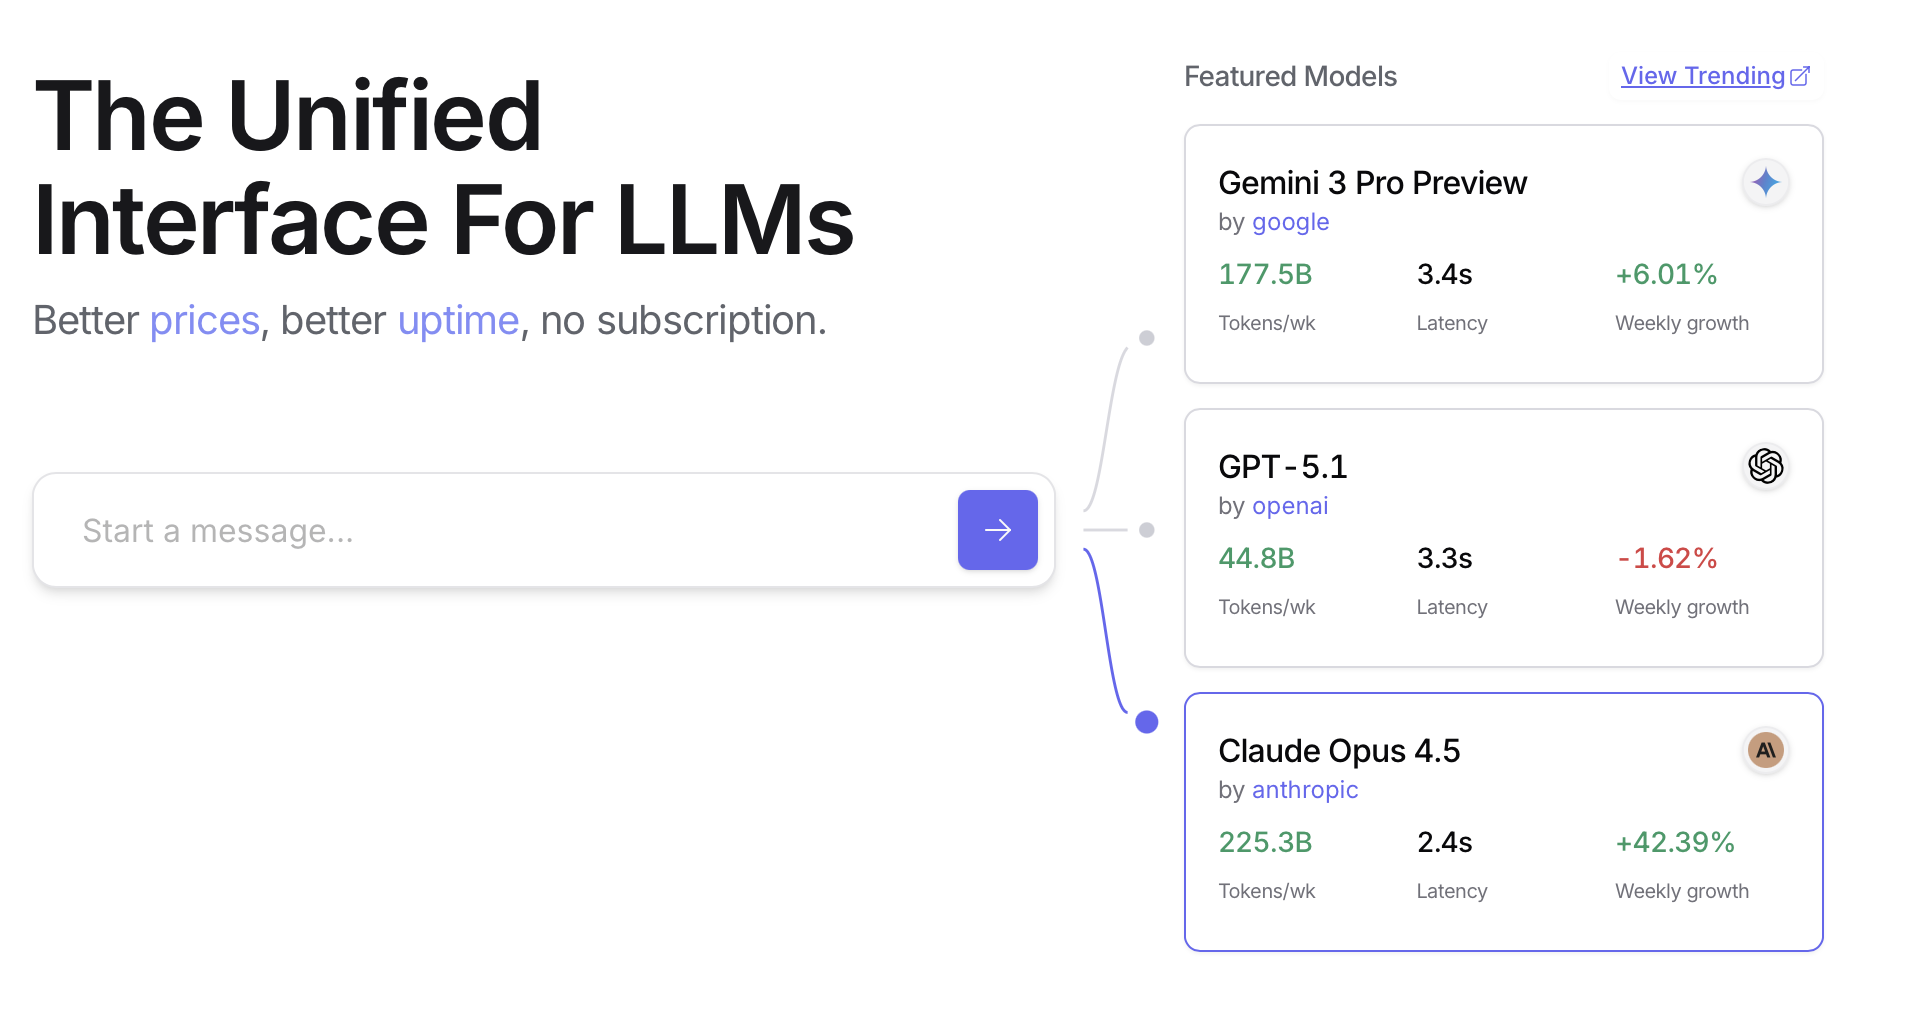

In [ ]:
from openrouter import OpenRouter

def query_openrouter(prompt, model_name="meta-llama/llama-3.1-70b-instruct"):
    """
    Connects to OpenRouter.

    CRITICAL CONCEPT: OpenRouter uses the OpenAI Client library!
    We just change the 'base_url' to OpenRouter's endpoint.
    This allows us to access Claude, Llama, Mistral, etc., using OpenAI-style code.
    """
    print(f"\n--- Querying OpenRouter ({model_name}) ---")
    with OpenRouter(api_key=userdata.get("OPENROUTER_APIKEY")) as client:
      response = client.chat.send(
          model=model_name,
          messages=[
              {"role": "user", "content": prompt}
          ],
      )
    return response.choices[0].message.content

In [ ]:
test_prompt = "What is the point of using nosql databases in engineering systems in under 3 sentences"

In [ ]:
# 1. Test OpenAI
print(query_openai(test_prompt))



--- Querying OpenAI (GPT-4.1 Mini) ---
NoSQL databases are used in engineering systems to handle large volumes of unstructured or semi-structured data with high scalability and flexibility. They enable rapid development by allowing schema-less designs and support distributed architectures for fault tolerance and performance. This makes them ideal for real-time analytics, IoT data, and applications requiring horizontal scaling.


In [ ]:
# 2. Test Anthropic
print(query_anthropic(test_prompt))



--- Querying Anthropic (Claude Haiku 4.5) ---
# NoSQL Databases in Engineering

NoSQL databases excel at handling **unstructured or rapidly evolving data** at massive scale, avoiding the rigid schema constraints of traditional SQL databases. They provide **horizontal scalability and high availability** through distributed architectures, making them ideal for systems requiring fast reads/writes and fault tolerance. They're particularly useful when **data structure varies significantly** or when you prioritize speed and flexibility over strict data consistency.


In [ ]:
# 3. Test Gemini
print(query_gemini(test_prompt))


--- Querying Google (Gemini 2.5 Flash) ---
NoSQL databases excel in engineering systems by offering superior **flexibility** for rapidly evolving data models and **horizontal scalability** to handle massive data volumes and high traffic. They provide high performance for specific access patterns, making them ideal for agile development and distributed applications where strict relational ACID properties are not the primary concern.


In [ ]:
# 4. Test OpenRouter (Accessing Grok 4 Fast 3 via OpenRouter)
# Notice we don't need a Grok API key, just the OpenRouter key.
print(query_openrouter(test_prompt, model_name="x-ai/grok-4.3"))



--- Querying OpenRouter (x-ai/grok-4.3) ---
NoSQL databases are primarily used in engineering systems for horizontal scalability and high throughput on large volumes of unstructured/semi-structured data, where relational databases hit limits on distribution and performance. Their flexible schemas also allow rapid iteration on evolving data models without migrations.


In [ ]:
# 5. Test OpenRouter (Accessing Deepseek-R1 via OpenRouter)
# Same code, different model string!
print(query_openrouter(test_prompt, model_name="deepseek/deepseek-r1"))


--- Querying OpenRouter (deepseek/deepseek-r1) ---
